# Classificação de Qualidade de Vinhos

In [1]:
# configuração para não exibir os warnings
import warnings
warnings.filterwarnings("ignore")

# Imports necessários
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

## Carga do Dataset

O dataset contém informações físico-químicas de vinhos tintos, com cada registro representando uma amostra. As variáveis incluem características como acidez, pH, teor alcoólico e sulfatos. A última coluna, `quality`, indica a nota de qualidade atribuída ao vinho.

In [2]:
url = "https://raw.githubusercontent.com/cclguedes/Classificador_Vinhos_Backend/refs/heads/main/dataset/WineQT.csv"

dataset = pd.read_csv(url, delimiter=',')
dataset.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## Análise Inicial

Inicialmente, foi realizada uma análise exploratória do dataset com o objetivo de compreender sua estrutura, qualidade e características principais.

Por meio da função `info()`, verificou-se que o conjunto de dados possui 1143 registros distribuídos em 13 colunas, todas compostas por variáveis numéricas. Além disso, observou-se que não há valores nulos em nenhuma das variáveis, indicando que o dataset está completo e não requer tratamento de dados ausentes.

Em seguida, foi utilizada a função `describe()` para obter estatísticas descritivas das variáveis, como média, desvio padrão, valores mínimos e máximos. Essa análise permitiu entender a distribuição dos dados e identificar que os valores estão dentro de faixas esperadas, sem indícios de inconsistências evidentes.

Por fim, a verificação de valores nulos foi reforçada com a função `isnull().sum()`, confirmando que todas as colunas possuem valores completos. Esse resultado simplifica o processo de pré-processamento, uma vez que não será necessário aplicar técnicas de imputação ou remoção de dados.

In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [4]:
dataset.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [5]:
dataset.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


## Transformação do Problema

A variável alvo original do dataset, denominada `quality`, é representada por valores numéricos inteiros que indicam a qualidade do vinho. No entanto, como o objetivo deste trabalho é aplicar técnicas de classificação supervisionada, foi necessário transformar essa variável em categorias discretas.

Para isso, foi definida uma função de categorização que agrupa os valores de qualidade em duas classes distintas: **"ruim"**, para valores menores ou iguais a 5; e **"bom"**, para valores maiores que 5. Essa abordagem converte o problema originalmente numérico em um problema de classificação binária, uma vez que a variável alvo passa a possuir duas categorias distintas.

A função foi aplicada a toda a coluna `quality`, gerando uma nova variável chamada `categoria`, que passa a representar a variável alvo do modelo.

Em seguida, foi realizada a análise da distribuição das classes por meio da função `value_counts()`. Observou-se que o dataset apresenta um leve desbalanceamento entre as classes, com predominância da categoria **"bom"**, o que pode influenciar o desempenho dos modelos.

Por fim, a coluna original `quality` foi removida do dataset, garantindo que o modelo não utilize diretamente a variável numérica original durante o treinamento. Essa etapa é fundamental para evitar vazamento de informação (data leakage).

In [6]:
def categorizar(q):
    if q <= 5:
        return "ruim"
    else:
        return "bom"

dataset["categoria"] = dataset["quality"].apply(categorizar)

# Distribuição das classes
print(dataset["categoria"].value_counts())
print()
print(dataset["categoria"].value_counts(normalize=True).mul(100).round(1).astype(str) + "%")

categoria
bom     621
ruim    522
Name: count, dtype: int64

categoria
bom     54.3%
ruim    45.7%
Name: proportion, dtype: object


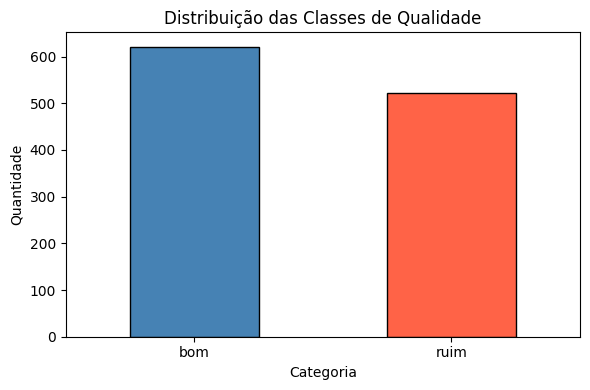

In [7]:
# Visualização da distribuição das classes
fig, ax = plt.subplots(figsize=(6, 4))
dataset["categoria"].value_counts().plot(kind="bar", ax=ax, color=["steelblue", "tomato"], edgecolor="black")
ax.set_title("Distribuição das Classes de Qualidade")
ax.set_xlabel("Categoria")
ax.set_ylabel("Quantidade")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

In [8]:
dataset = dataset.drop(columns=["quality"])

## Separação das Variáveis

Nesta etapa, o dataset foi dividido em variáveis independentes (X) e variável alvo (y), conforme exigido em problemas de aprendizado supervisionado.

As variáveis independentes (X) correspondem às características físico-químicas do vinho, que serão utilizadas como entrada para o modelo. Para isso, foram removidas as colunas `categoria` e `Id`, sendo a primeira a variável alvo e a segunda apenas um identificador, sem relevância para o processo de aprendizado.

A variável alvo (y) foi definida como a coluna `categoria`, que representa a classificação da qualidade do vinho em duas classes distintas: **"ruim"** e **"bom"**.

In [9]:
X = dataset.drop(columns=["categoria", "Id"])
y = dataset["categoria"]

print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)

Dimensão de X: (1143, 11)
Dimensão de y: (1143,)


## Separação em Conjunto de Treino e Teste

Nesta etapa, os dados foram divididos em dois subconjuntos: treino e teste, utilizando a técnica de holdout.

Foi definida uma proporção de **80% dos dados para treinamento** e **20% para teste**. O conjunto de treino é utilizado para ajustar o modelo, enquanto o conjunto de teste é reservado para avaliar seu desempenho em dados não vistos, permitindo uma estimativa mais realista da capacidade de generalização.

A divisão foi realizada de forma **estratificada**, por meio do parâmetro `stratify=y`, garantindo que a proporção das classes seja mantida em ambos os conjuntos. Essa abordagem é especialmente importante devido ao desbalanceamento observado nas classes do dataset.

Além disso, foi definida uma semente aleatória (`random_state=7`) para garantir a reprodutibilidade dos resultados. Por fim, foi configurada a validação cruzada estratificada (**Stratified K-Fold**) com 10 partições, que será utilizada para avaliar os modelos de forma mais robusta.

In [10]:
test_size = 0.20
seed = 7

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    random_state=seed,
    stratify=y
)

kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)

print(f"Tamanho do conjunto de treino: {X_train.shape[0]} amostras")
print(f"Tamanho do conjunto de teste:  {X_test.shape[0]} amostras")

Tamanho do conjunto de treino: 914 amostras
Tamanho do conjunto de teste:  229 amostras


## Modelagem

Nesta etapa, foram aplicados diferentes algoritmos de classificação supervisionada com o objetivo de identificar qual modelo apresenta melhor desempenho para o problema proposto.

Foram selecionados quatro algoritmos clássicos amplamente utilizados em tarefas de classificação: **K-Nearest Neighbors (KNN)**, **Árvore de Decisão (CART)**, **Naive Bayes (NB)** e **Support Vector Machine (SVM)**. A escolha desses modelos permite comparar abordagens distintas, baseadas em diferentes princípios, como distância, regras de decisão, probabilidade e separação por margens.

Para avaliar o desempenho dos modelos de forma mais robusta, foi utilizada a técnica de **validação cruzada estratificada (Stratified K-Fold)** com 10 partições, garantindo que a proporção das classes seja mantida em cada divisão dos dados.

A métrica adotada para avaliação foi a **acurácia**, que mede a proporção de previsões corretas realizadas pelo modelo.

In [11]:
np.random.seed(seed)

models = []
models.append(("KNN", KNeighborsClassifier()))
models.append(("CART", DecisionTreeClassifier()))
models.append(("NB", GaussianNB()))
models.append(("SVM", SVC()))

results = []
names = []

for name, model in models:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
    results.append(cv_results)
    names.append(name)
    print(f"{name}: {cv_results.mean():.4f} ({cv_results.std():.4f})")

KNN: 0.6619 (0.0552)
CART: 0.7220 (0.0674)
NB: 0.7221 (0.0651)
SVM: 0.6313 (0.0466)


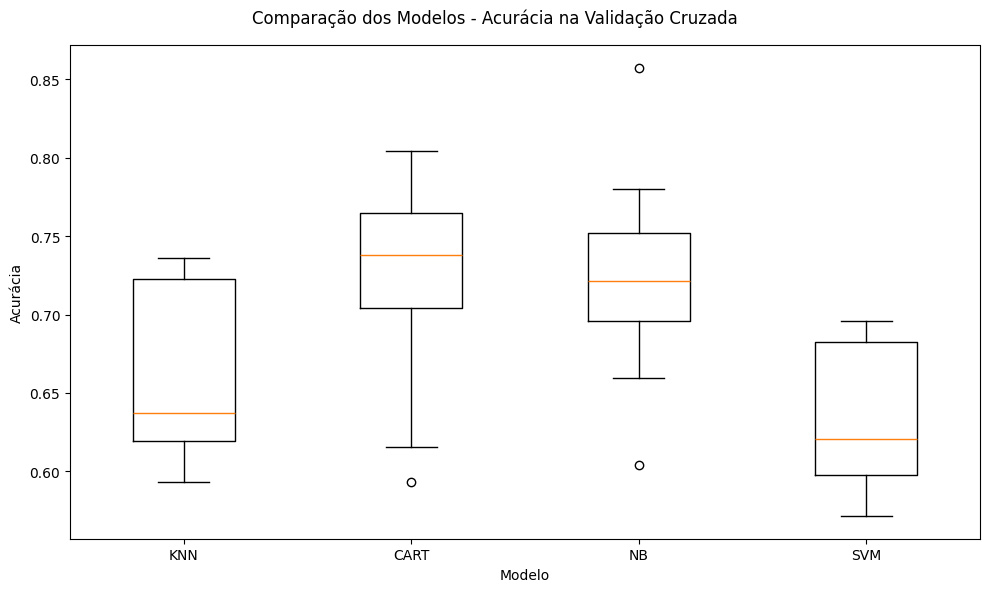

In [12]:
# Boxplot de comparação dos modelos
fig = plt.figure(figsize=(10, 6))
fig.suptitle('Comparação dos Modelos - Acurácia na Validação Cruzada')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
ax.set_ylabel("Acurácia")
ax.set_xlabel("Modelo")
plt.tight_layout()
plt.show()

## Avaliação Final

Após a etapa de modelagem e comparação entre os algoritmos, foi selecionado o modelo **CART (Árvore de Decisão)** para avaliação final utilizando o conjunto de teste, que não foi utilizado durante o treinamento.

O CART foi escolhido por ter apresentado o **melhor desempenho médio na validação cruzada** entre os quatro algoritmos avaliados. Além disso, árvores de decisão têm a vantagem de não serem sensíveis à escala dos dados, dispensando a etapa de padronização — ao contrário do SVM, que performa mal quando as variáveis estão em escalas diferentes.

O modelo foi treinado diretamente com os dados de treino originais (sem padronização) e avaliado no conjunto de teste. A avaliação foi feita por meio da **acurácia** e do **relatório de classificação**, que apresenta métricas complementares como precisão, recall e F1-score para cada classe.

In [13]:
# Modelo final: CART (Árvore de Decisão)
model = DecisionTreeClassifier(random_state=seed)
model.fit(X_train, y_train)

# Avaliação no conjunto de teste
predictions = model.predict(X_test)

print("Acurácia:", accuracy_score(y_test, predictions))
print()
print("Relatório de Classificação:")
print(classification_report(y_test, predictions))

Acurácia: 0.6986899563318777

Relatório de Classificação:
              precision    recall  f1-score   support

         bom       0.70      0.77      0.74       124
        ruim       0.70      0.61      0.65       105

    accuracy                           0.70       229
   macro avg       0.70      0.69      0.69       229
weighted avg       0.70      0.70      0.70       229



## Simulação

Após o treinamento e avaliação do modelo, foi realizada uma simulação utilizando um novo conjunto de dados, com o objetivo de demonstrar sua aplicação prática.

Para isso, foi criado um exemplo fictício contendo valores das variáveis físico-químicas de um vinho, organizados no mesmo formato utilizado durante o treinamento do modelo.

Como o CART não é sensível à escala dos dados, **não é necessário aplicar padronização** antes da predição. Os dados de entrada são utilizados diretamente pelo modelo para prever a classe correspondente ao novo exemplo: **"ruim"** ou **"bom"**.

In [14]:
# Novo vinho fictício (mesma ordem das colunas de X)
novo_vinho = np.array([[7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4]])

# Predição (CART não requer padronização)
pred = model.predict(novo_vinho)
print("Classe prevista:", pred[0])

Classe prevista: ruim


## Salvando os Arquivos

In [15]:
# Salvando o modelo
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!


## Conclusão

Neste trabalho, foi possível aplicar técnicas clássicas de machine learning para a **classificação da qualidade de vinhos**, percorrendo todas as etapas do processo: análise exploratória dos dados, transformação do problema, separação em treino e teste, modelagem comparativa e avaliação final.

A análise exploratória confirmou que o dataset está completo e sem valores ausentes. A transformação da variável alvo de numérica para categórica binária ("ruim" / "bom") viabilizou a aplicação de algoritmos de classificação supervisionada.

Na etapa de modelagem, foram comparados quatro algoritmos — KNN, CART, Naive Bayes e SVM — por meio de validação cruzada estratificada com 10 partições. O **CART (Árvore de Decisão)** foi selecionado como modelo final por apresentar o **melhor desempenho médio na validação cruzada**, além da vantagem de não exigir padronização dos dados.

Os resultados obtidos demonstram que o modelo é capaz de capturar padrões relevantes nas características físico-químicas dos vinhos, classificando corretamente a qualidade na maioria dos casos. Por fim, a simulação com um novo vinho fictício evidenciou a aplicabilidade prática do modelo desenvolvido.